# Bike Share Demo: Do Casual Riders Take Longer Trips?
SDEV2501 - Practice in Notebooks

## The question
Do casual riders take longer bike trips than members, and if so, by how much?

A real bike-share company would use this to set pricing, decide how long a free ride window should be, and figure out where to move bikes during the day. We'll go through the usual steps: load the data, look at it, clean up any problems, run some stats, make a couple charts, then answer the question.

The dataset (`bike_share_mock.csv`) is made up: 400 simulated rides from a fictional city bike-share program. It's built to behave like real data, messy rows and all, so it's safe to poke at live in class.

In [ ]:
import pandas as pd              # for loading and working with the data
import matplotlib.pyplot as plt  # for the histogram and boxplot later

pd.set_option("display.max_columns", None)  # so we can see all the columns when previewing

## 1. Load and preview
Step one with any new dataset: load it up and take a look.

In [ ]:
df = pd.read_csv("bike_share_mock.csv")  # load the CSV into a DataFrame
df.head()  # first 5 rows, just to see what a ride record looks like

,ride_id,start_time,member_type,duration_min,start_station,end_station
0,1334,2026-05-01 01:25:00,casual,10.8,Legislature Grounds,Grandin Station
1,1173,2026-05-01 17:56:00,member,5.1,Grandin Station,Grandin Station
2,1191,2026-05-01 21:11:00,casual,39.6,MacEwan University,Riverdale
3,1104,2026-05-02 12:18:00,casual,27.4,Kinnaird Ravine,Riverdale
4,1257,2026-05-02 18:18:00,casual,58.8,Riverdale,Whyte Ave & 104 St


In [ ]:
print("Shape (rows, columns):", df.shape)  # how many rides do we have?
df.dtypes  # what type did pandas infer for each column?

Shape (rows, columns): (400, 6)


ride_id            int64
start_time           str
member_type          str
duration_min     float64
start_station        str
end_station          str
dtype: object

## 2. Check for problems before trusting any number
Remember messy data earlier in the course? We can clean it.

In [ ]:
df.isna().sum()  # count missing values per column

ride_id           0
start_time        0
member_type       0
duration_min     12
start_station     0
end_station       0
dtype: int64

`duration_min` is missing for a few rides, probably a dock sensor that glitched and never logged the end time. We can't run stats on a missing number, so we'll drop those rows in a copy and leave the original file alone.

In [ ]:
df_clean = df.dropna(subset=["duration_min"]).copy()  # drop only rows missing a duration
print(f"Kept {len(df_clean)} of {len(df)} rides ({len(df) - len(df_clean)} dropped for missing duration)")

Kept 388 of 400 rides (12 dropped for missing duration)


## 3. Summary stats, then split by group

In [ ]:
df_clean["duration_min"].describe()  # count, mean, std, min, quartiles, max — all at once

count    388.000000
mean      18.257474
std       36.132251
min        2.400000
25%        7.800000
50%       11.000000
75%       17.125000
max      380.700000
Name: duration_min, dtype: float64

The mean (about 18 min) is way above the median (about 11 min). That's what a right-skewed distribution looks like: most rides are short, but a handful of really long ones drag the average up. Makes sense for trip durations, and it's a reminder to be careful which stat we lean on later.

Now let's actually split by rider type, since that's what the question is about:

In [ ]:
# .groupby() splits the rows by member_type, then we ask for a few stats on duration_min within each group
df_clean.groupby("member_type")["duration_min"].agg(["mean", "median", "std", "count"]).round(2)

,mean,median,std,count
member_type,,,,
casual,24.17,18.35,30.17,138
member,14.99,9.25,38.71,250


## 4. Charts, not just numbers

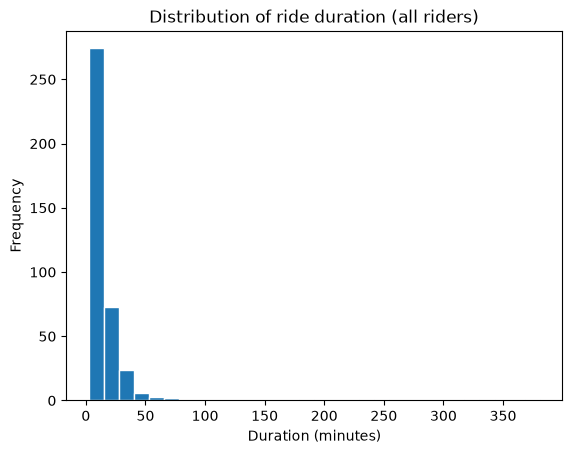

In [ ]:
df_clean["duration_min"].plot(kind="hist", bins=30, edgecolor="white")
plt.title("Distribution of ride duration (all riders)")
plt.xlabel("Duration (minutes)")
plt.show()

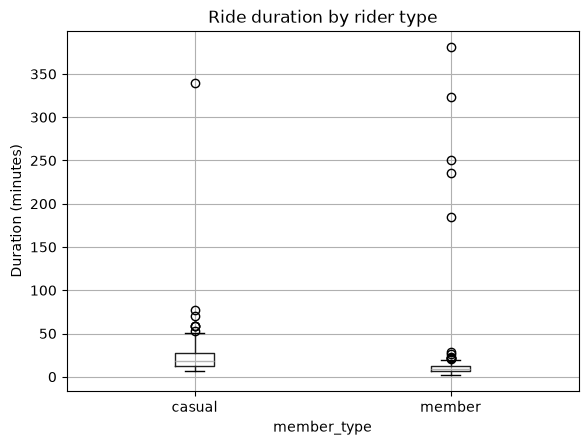

In [ ]:
# a boxplot per group shows the median, the middle 50% (the box), and flags points past the whiskers as potential outliers
df_clean.boxplot(column="duration_min", by="member_type")
plt.title("Ride duration by rider type")
plt.suptitle("")  # pandas adds an extra automatic title we don't need
plt.ylabel("Duration (minutes)")
plt.show()

## 5. Outliers: run the 1.5xIQR rule, then use your own judgment
Same fence rule from the Day 04 bike rental example, just on 388 rides instead of 11 numbers.

In [ ]:
q1 = df_clean["duration_min"].quantile(0.25)
q3 = df_clean["duration_min"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"Q1={q1}, Q3={q3}, IQR={iqr:.2f}")
print(f"Fences: below {lower_fence:.2f} or above {upper_fence:.2f}")

flagged = df_clean[df_clean["duration_min"] > upper_fence]
print(f"\nThe 1.5xIQR rule flags {len(flagged)} rides as statistical outliers.")

Q1=7.8, Q3=17.125, IQR=9.32
Fences: below -6.19 or above 31.11

The 1.5xIQR rule flags 32 rides as statistical outliers.


That's a lot of outliers. Since ride duration is naturally skewed, this rule ends up flagging plenty of normal long rides, not just bad data. It's a starting point, not the final word, so let's use some common sense instead: a ride over 2 hours is a much better sign that a bike just never got docked.

In [ ]:
likely_errors = df_clean[df_clean["duration_min"] > 120]  # over 2 hours
likely_errors[["ride_id", "member_type", "duration_min", "start_station"]].sort_values(
    "duration_min", ascending=False
)

,ride_id,member_type,duration_min,start_station
127,1036,member,380.7,Rossdale
22,1214,casual,339.3,Whyte Ave & 104 St
323,1249,member,323.0,Legislature Grounds
175,1066,member,250.7,Whyte Ave & 104 St
15,1349,member,235.5,Bonnie Doon
369,1165,member,184.4,Legislature Grounds


## 6. So, do casual riders take longer trips?

Yes. The median casual ride is about 18 minutes, versus about 9 minutes for members, so a casual rider's typical trip is roughly twice as long. We're leading with the median here, not the mean, because a few multi-hour rides (probably forgotten docks, not real trips) drag the member average up and make the two groups look closer than they actually are. Same mean-vs-median lesson from Day 04, just showing up in an actual dataset this time instead of a toy example.

In practice, this fits members using bikes for quick commutes and casual riders taking longer, more relaxed trips. Handy to know if you're an operator trying to figure out how to price memberships versus single rides.